In [1]:
import pickle
import os

import numpy as np 
import geopandas as gpd
import jax
import jax.numpy as jnp
from jax import random

import numpyro 
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import sys 
import matplotlib.pyplot as plt 
import plotly.graph_objs as go

sys.path.append(os.path.pardir)
import numpy as np
from aggGP import exp_sq_kernel
from aggVAE import vae_decoder

import time

jax.config.update("jax_default_device", jax.devices()[0])
print(f"Jax using device : {jax.devices()}")


Jax using device : [CudaDevice(id=0), CudaDevice(id=1)]


In [14]:
# ------------------------------ Load variables ------------------------------ #
# root directory
var_dir = "../data/processed"
# Lat/Lon Values of artificial grid
x = np.load(os.path.join(var_dir,"lat_lon_x.npy")) #(2618,2)
# Low regional data
pol_pt_lo = np.load(os.path.join(var_dir,"low","pol_pt_lo.npy")) #(9,2618)
pt_which_pol_lo = np.load(os.path.join(var_dir,"low","pt_which_pol_lo.npy")) #(2618,)
# High regional data 
pol_pt_hi = np.load(os.path.join(var_dir,"high","pol_pt_hi.npy")) #(49, 2618,)
pt_which_pol_hi = np.load(os.path.join(var_dir,"high","pt_which_pol_hi.npy")) #(2618,)
# Dataframes
df_lo = gpd.read_file(os.path.join(var_dir, "low", "us_census_divisions","us_census_divisions.shp"))
df_hi = gpd.read_file(os.path.join(var_dir, "high", "us_state_divisions","us_state_divisions.shp"))

In [15]:
# ---------------------------- Arguments to Model ---------------------------- #
args = {
    #"n_low_obs" : df_lo.tot_cases, #observarions <- This is passed as y
    "n_specimens_lo" : jnp.array(df_lo.tot_specs),
    "n_specimens_hi" : jnp.array(df_hi.tot_specs),  
    "x" : jnp.array(x),
    "gp_kernel" : exp_sq_kernel,
    "jitter" : 1e-4,
    "noise" : 1e-4,
    "M_lo" : pol_pt_lo,
    "M_hi" : pol_pt_hi,

    # VAE training
    "rng_key": random.PRNGKey(5),
    "num_epochs": 20, 
    "learning_rate": 0.0005, 
    "batch_size": 100, 
    "hidden_dim": 50, 
    "z_dim": 40, 
    "num_train": 100,
    "num_test":100,
    "vae_var": 1,
    # GP-Kernel Hyperparams
    "kernel_length" : dist.InverseGamma(3,3), #!hyperparam
    "kernel_var" : dist.HalfNormal(0.05) #!hyperparam
}

In [16]:
# ---------------------------- Load Decoder Model ---------------------------- #
with open("../model_weights/aggVAE_Dec_e100_h50_z40", "rb") as file:
    vae_params = pickle.load(file)

encoder_params = vae_params["encoder$params"]
decoder_params = vae_params["decoder$params"]
# save decoder params inside args
args["decoder_params"] = decoder_params

In [17]:
# ---------------------------- Just some test code --------------------------- #
z_dim, h_dim = decoder_params[0][0].shape # 40 , 50
N = df_lo.shape[0] + df_hi.shape[0] 
dec_init_fn, dec_apply_fn = vae_decoder(h_dim , N) # cae_decoder(50,58)
z_test = random.normal(random.PRNGKey(0), shape = (5, 40)) #(* 40)
X_recon_test = dec_apply_fn(params = decoder_params,inputs = z_test)
print(f"Reconstructed X test shape : {X_recon_test.shape}")


Reconstructed X test shape : (5, 58)


In [18]:
def vae_sample(args):
    dec_params = args["decoder_params"]
    z_dim, h_dim = dec_params[0][0].shape 
    z = numpyro.sample("z", dist.Normal(jnp.zeros(z_dim), jnp.ones(z_dim)))
    dec_init_fn, dec_apply_fn = vae_decoder(h_dim, N)
    x_recon = dec_apply_fn(dec_params, z)
    vae_aggr = numpyro.deterministic("vae_aggr", x_recon)
    return vae_aggr

rng_key, rng_key_predict = random.split(random.PRNGKey(3))
vae_predictive = Predictive(vae_sample, num_samples = 12)
vae_draws = vae_predictive(rng_key_predict, args)["vae_aggr"] #(num_samples, 58)


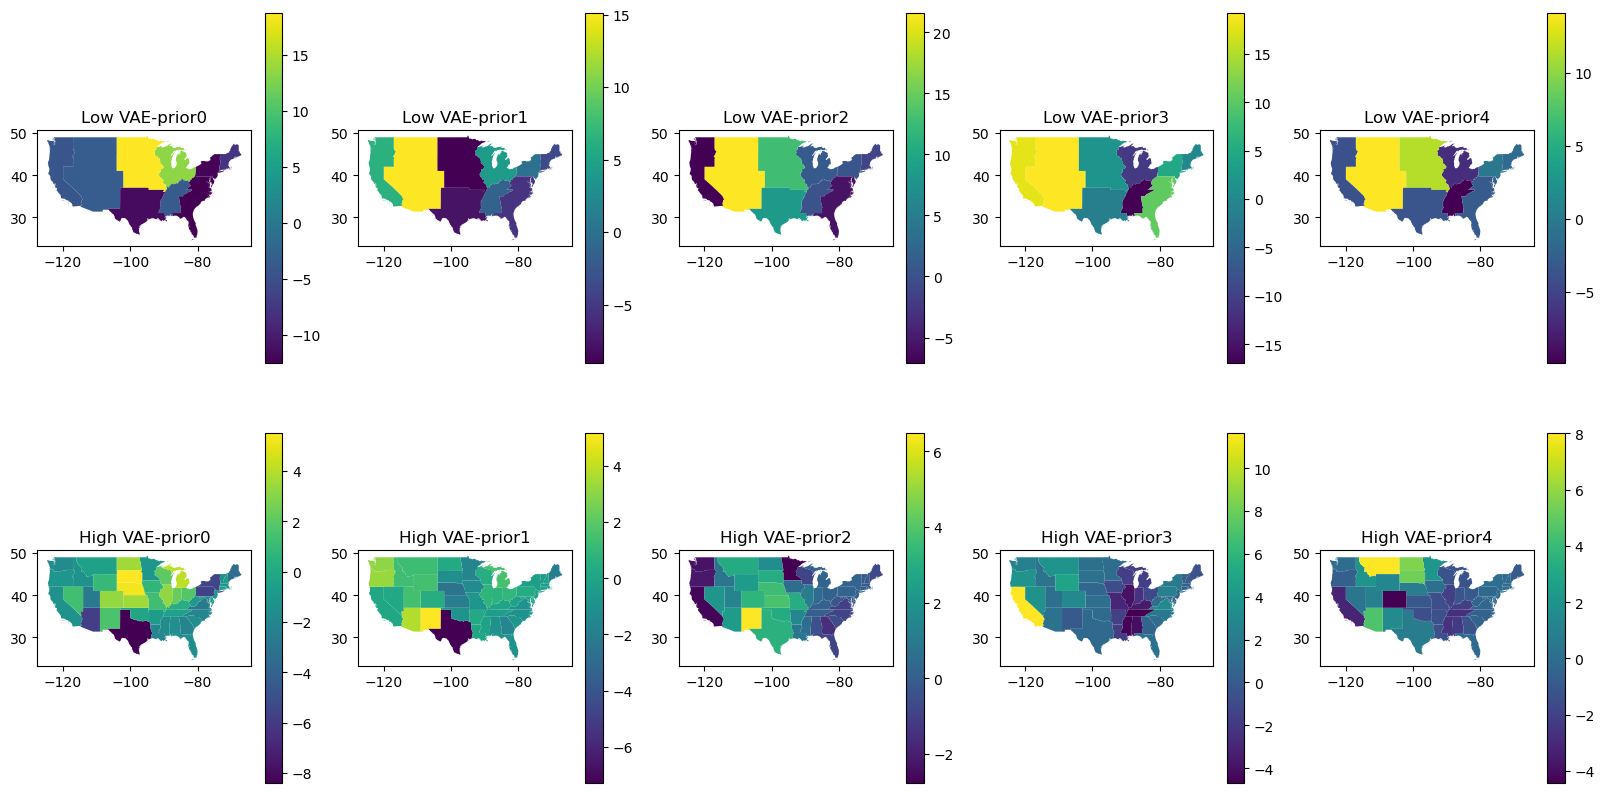

In [19]:
n_lo = 9
n_hi = 49
fig, axs = plt.subplots(2,5, figsize = (20,10))

#! There is aggGP code here which is ignored ...

for i in range(5):
    nm = 'Low : vae_draw_' + str(i)
    df_lo[nm] = vae_draws[i,0:n_lo]
    df_lo.plot(column=nm, ax=axs[0,i], legend=True)
    axs[0,i].set_title( 'Low VAE-prior' + str(i))
    
for i in range(5):
    nm = 'High : vae_draw_' + str(i)
    df_hi[nm] = vae_draws[i,n_lo:(n_lo + n_hi)]
    df_hi.plot(column=nm, ax=axs[1,i], legend=True)
    axs[1,i].set_title( 'High VAE-prior' + str(i))

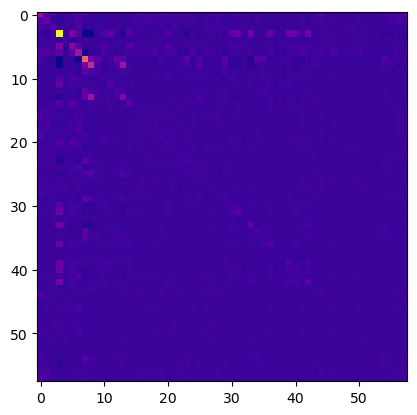

In [20]:

#! There is aggGP code ignored here

vae_predictive = Predictive(vae_sample, num_samples= 100)
vae_draws = vae_predictive(rng_key_predict, args)["vae_aggr"]
m_vae = np.cov(np.transpose(vae_draws))
plt.imshow(m_vae, cmap = "plasma")

In [21]:
import plotly.graph_objects as go
import plotly.express as px

In [22]:
p1 = px.line()
region_colors = px.colors.qualitative.Plotly
for i in range(10):
    p1.add_scatter(
        #x = np.arange(1, len(vae_draws) + 1),
        x = df_hi["area"],
        y = vae_draws[i,:],
        line = dict(color = "blue", width = 2),
        marker = dict(color = region_colors[i], size = 10),
        name = f"gp_draw{i + 1}"
    )

p1.update_layout(
    template = "plotly_white", 
    xaxis_title = "region", 
    yaxis_title = "VAE-GP Spatial Prior", 
    title = "Reconstructed aggVAE Gaussian Process Spatial Prior Realizations",
    width = 1000, height = 400, 
    xaxis = dict(
        tickmode = "array",
        #ticktext = [f"R{i}" for i in range(1, len(vae_draws+1))]
    ) 
)

p1.add_shape(
    type="rect",
    x0=0, x1=9,  # Before x=9, low resolution region
    y0=-30, y1=30,  # Cover the entire y-axis region
    fillcolor="lightblue", opacity=0.3, line_width=0  # Light blue background for low resolution
)

p1.add_shape(
    type="rect",
    x0=9, x1=49,  # Before x=9, low resolution region
    y0=-30, y1=30,  # Cover the entire y-axis region
    fillcolor="orange", opacity=0.3, line_width=0  # Light blue background for low resolution
)

p1.add_annotation(
    x=4.5, y=25,  # Center the text over the low-resolution region
    text="Low Resolution Regions",  # Label for low resolution
    showarrow=False,
    font=dict(size=12, color="black")
)

p1.add_annotation(
    x=30, y=25,  # Center the text over the low-resolution region
    text="High Resolution Region",  # Label for low resolution
    showarrow=False,
    font=dict(size=12, color="black")
)

p1.show()
